In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.datasets import mnist

from keras.layers import Dense, Flatten, Convolution2D, MaxPooling2D, Reshape

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')


In [3]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


# CNN

<br>

>Les couches de convolutions ont pour rôle d'extraire l'information inmportante des images à l'aide de filtres.
>
>Les pooling doit permettre de réduire la quantité de pixels.
>
>C'est la combinaison des couches de convolution et de pooling qui permet d'extraire les features intéressantes, de retirer le bruit tout en réduisant la quantité de paramètres.

In [ ]:
def get_cnn(n_class, activation: str = 'relu') -> keras.Sequential:
    model = keras.Sequential([
        # Convolution layers need 3 dimensions for the images.
        # The third dimensions is for the color channels
        Reshape((28, 28, 1)),

        Convolution2D(filters=16, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Convolution2D(filters=32, kernel_size=2, activation=activation),
        MaxPooling2D(2),

        Flatten(),

        Dense(50, activation=activation),
        Dense(50, activation=activation),

        Dense(n_class, activation='softmax')

    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
    plt.show()


def plot_cm(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 8))
    plt.title('Confusion Matrix\n')
    sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()


In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape


(60000, 28, 28)

> On divise les images par 255 pour obtenir des valeurs comprises entre 0 et 1.
>
>L'intérêt principal est d'éviter de saturer les couches d'activation telles que sig ou tanh.
>
>De manière générale cela permet de converger plus vite vers des poids optimaux.

<br>

```py
def sigmoid(x):
    return 1/(1+np.exp(-x))

print(sigmoid(255))
>>>1.0

print(sigmoid(100))
>>>1.0

print(sigmoid(255/255))
>>>0.7310585786300049

print(sigmoid(100/255))
>>>0.596801812088207

```

In [6]:
# We could do it in the model with and Rescaling layer
X_train = X_train/255
X_test = X_test/255

X_train.dtype

dtype('float64')

In [7]:
cnn = get_cnn(10)
cnn.fit(X_train, y_train, epochs=10, validation_split=.2, batch_size=1024)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6050 - loss: 1.3334 - val_accuracy: 0.8702 - val_loss: 0.4453
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8939 - loss: 0.3559 - val_accuracy: 0.9280 - val_loss: 0.2578
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9337 - loss: 0.2264 - val_accuracy: 0.9500 - val_loss: 0.1737
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9507 - loss: 0.1641 - val_accuracy: 0.9629 - val_loss: 0.1346
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9618 - loss: 0.1270 - val_accuracy: 0.9693 - val_loss: 0.1097
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9677 - loss: 0.1060 - val_accuracy: 0.9703 - val_loss: 0.0998
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9715 - loss: 0.0934 - val_accuracy: 0.9741 - val_loss: 0.0905
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9745 - loss: 0.0830 - val_accuracy: 0.9717 - v

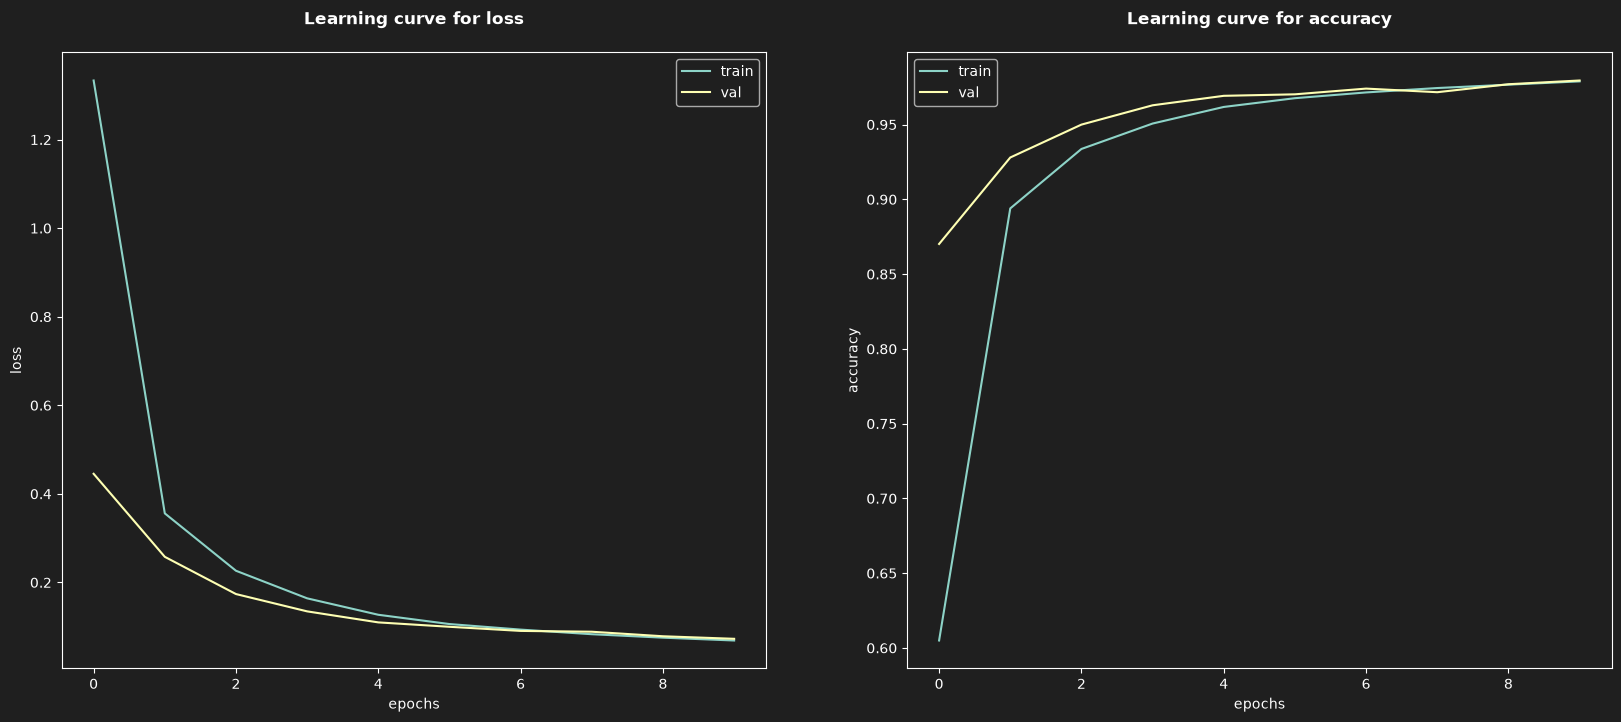

In [8]:
history = cnn.history.history

plot_lc(history)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


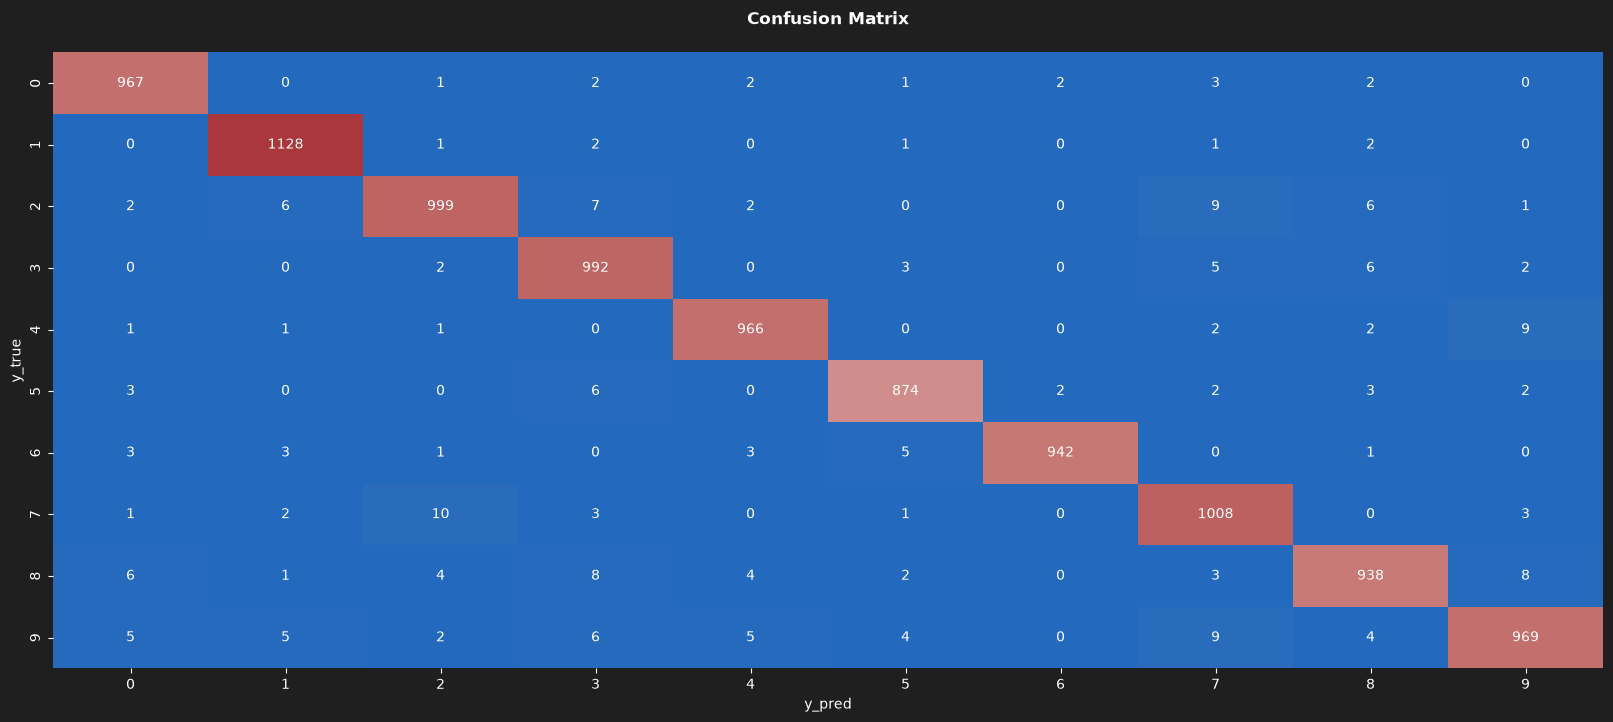

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       1.00      0.98      0.99       958
           7       0.97      0.98      0.97      1028
           8       0.97      0.96      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [9]:
y_pred = np.argmax(cnn.predict(X_test), -1)

plot_cm(y_test, y_pred)
print(classification_report(y_test, y_pred))


# Calcul des paramètres

>pour les couches de convolution:
>
>>$$(i*j)*n \space filters*n \space channels+n \space filters$$
>>
>>où i,j = shape du kernel
>>
>>n_filters = nombre de filtres en sortie
>>
>>n_channels = nombre de channels/filtres en entrée
>>
>>n_filtres = correspond aux biais des 16 neuronnes/filtres
>>
>>pour la première convolution:
>>```py
>>(2*2)*16*1+16
>>>>>80
>>```
>>
>>pour la seconde convolution:
>>```py
>>(2*2)*32*16+32
>>>>>2080
>>```
>
>pour les couches denses:
>
>$$n \space features*n \space units+n \space units$$
>
>>Première couche dense:
>>```py
>>1152*50+50
>>>>>57650
>>```
>>
>>Deuxième couche dense:
>>```py
>>50*50+50
>>>>>2550
>>```
>>
>>troisième couche dense:
>>```py
>>50*10+10
>>>>>510
>>```
>>



In [10]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (1024, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1024, 27, 27, 16)     │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1024, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1024, 12, 12, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1024, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1024, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1024, 50)             │        57,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1024, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1024, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,612 (736.77 KB)

 Trainable params: 62,870 (245.59 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 125,742 (491.18 KB)

# Inspectons les convolutions et pooling


Pour pouvoir voir les images après leur passage dans une couche de convolution et de pooling, nous devons modifier la sortie de notre modèle.

Actuellement, la sortie correspond à la dernière couche lorsqu'on procède à un predict.

On peut changer ce comportement pour que lors d'un predict ce ne soit pas les outputs de la dernière couche qui soient renvoyées mais les outputs d'une autre couche.

<br>

In [11]:
# lets print the name and the index for each layer in our cnn
for i, layer in enumerate(cnn.layers):
    print(i, layer.name)

0 reshape
1 conv2d
2 max_pooling2d
3 conv2d_1
4 max_pooling2d_1
5 flatten
6 dense
7 dense_1
8 dense_2


In [17]:
cnn.layers[-1].weights

[<Variable path=sequential/dense_2/kernel, shape=(50, 10), dtype=float32, value=[[ 2.64723629e-01  1.51216269e-01  2.46024728e-01  2.62771189e-01
   -1.20795310e-01  2.37452298e-01  3.16904485e-01 -2.02449813e-01
    1.56797364e-01 -2.33091891e-01]
  [ 9.82314572e-02 -3.28694522e-01 -3.56951565e-01  1.94746837e-01
    2.32349485e-02 -1.25135154e-01 -1.96450859e-01  9.97174010e-02
    2.17648879e-01  8.35673958e-02]
  [ 3.23593080e-01 -6.64703920e-02  1.33540764e-01  2.15512022e-01
    7.67579377e-02  1.66064769e-01 -2.54754543e-01 -3.39134783e-01
   -5.47313616e-02  1.52917817e-01]
  [ 7.57783465e-03 -8.43606591e-02 -3.80506217e-02  1.52235642e-01
   -2.10677952e-01 -1.78890198e-01  2.56337494e-01  3.46538275e-02
    1.17740594e-01 -3.17276478e-01]
  [-2.07877997e-03 -1.98451765e-02  5.50589748e-02 -6.58260584e-02
    1.27372473e-01 -9.70182195e-03  1.92082986e-01  5.06781861e-02
    2.11328253e-01  2.57904708e-01]
  [ 1.88595042e-01  2.59104788e-01  1.06244847e-01 -2.54927129e-01
    

/tmp/ipykernel_65640/129707683.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

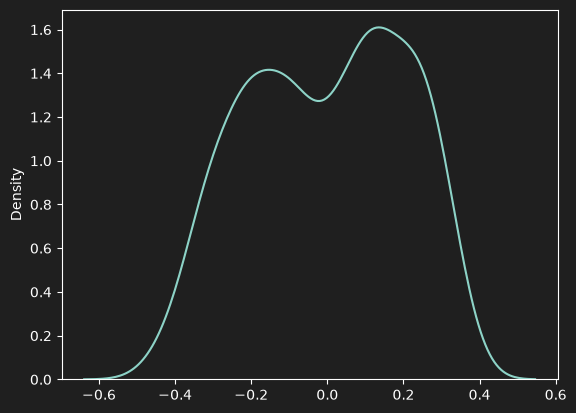

In [20]:
sns.kdeplot(np.array(cnn.layers[-1].weights[0]).ravel())

/tmp/ipykernel_65640/1103412625.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(cnn.layers[-1].weights[0]))


<Axes: ylabel='Density'>

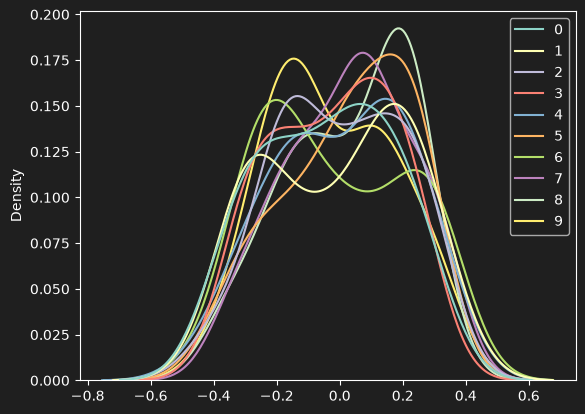

In [21]:
sns.kdeplot(np.array(cnn.layers[-1].weights[0]))

In [12]:
# New model taking the input of our model as the inputs => no change
# Let's set outputs of our new model as the outputs of a pooling layer
filters_gen = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[2].output)

# f_maps = features map (i.e. the features extracted by the conv layer)
f_maps = filters_gen.predict(X_test)
f_maps.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


(10000, 13, 13, 16)

In [23]:
for idx, layer in enumerate(cnn.layers):
    if 'conv' in layer.name:
        print(idx, layer.name)

1 conv2d
3 conv2d_1


In [22]:
for idx, layer in enumerate(cnn.layers):
      print(f'{idx} - {layer.name}')

0 - reshape
1 - conv2d
2 - max_pooling2d
3 - conv2d_1
4 - max_pooling2d_1
5 - flatten
6 - dense
7 - dense_1
8 - dense_2


In [25]:

# features maps extractor model
map_extractor = keras.Model(inputs=cnn.inputs
                      , outputs=cnn.layers[4].output)

In [26]:

# features maps extractor model
f_map_extractor = keras.Model(inputs=cnn.inputs
                      , outputs=cnn.layers[4].output)
f_map = f_map_extractor. predict(X_test)
f_map.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 6, 6, 32)

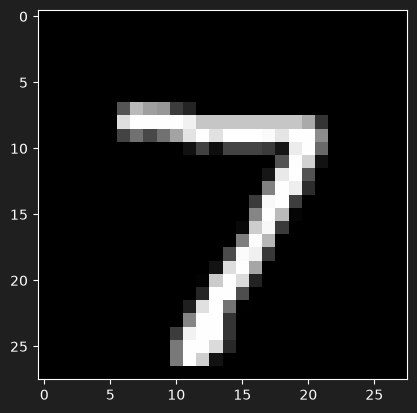

In [27]:
# plot the original img 
plt.imshow(X_test[0], cmap='gray')
plt.show()

## Après la première conv

<br>

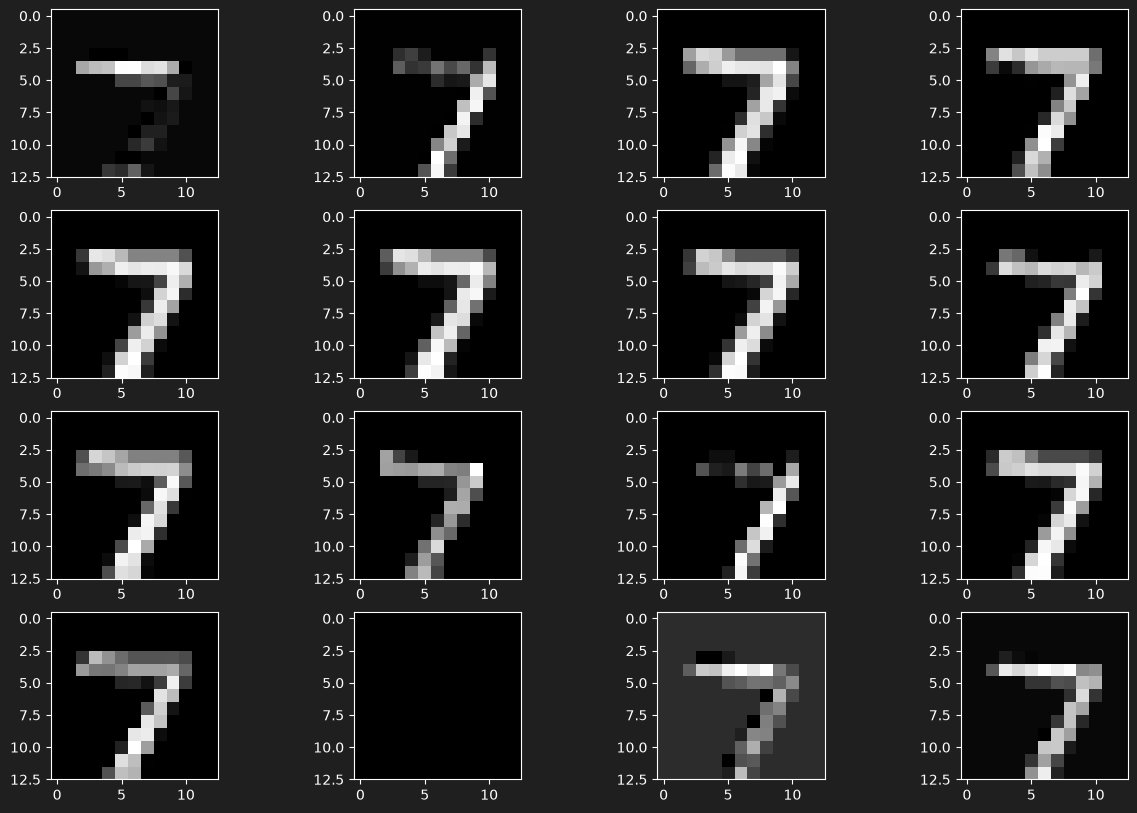

In [14]:
plt.figure(figsize=(15, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # f_maps[0, :, :, i] means [first img, all pixels, all pixels, i filter]
    plt.imshow(f_maps[0, :, :, i], cmap='gray')
plt.show()

In [15]:
filters_gen = keras.Model(inputs=cnn.inputs, outputs=cnn.layers[4].output)

f_maps = filters_gen.predict(X_test)
f_maps.shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 6, 6, 32)

## Après la seconde conv

<br>

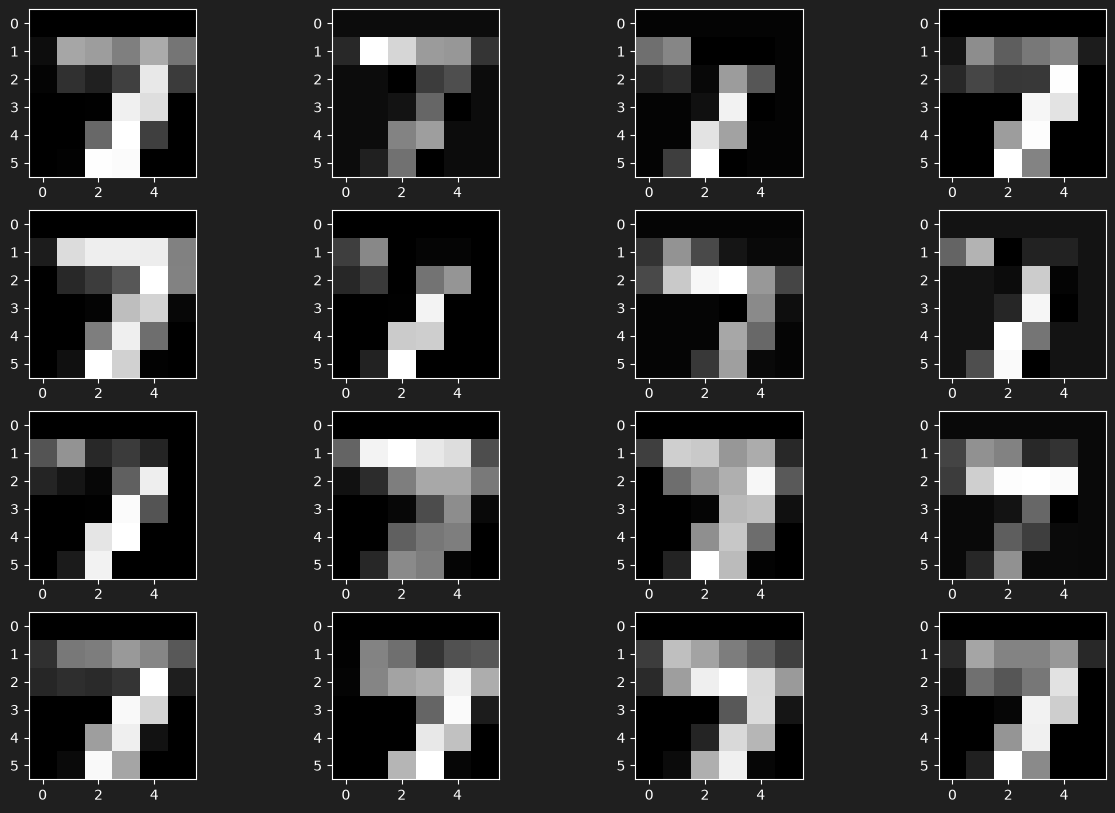

In [16]:
plt.figure(figsize=(15, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(f_maps[0, :, :, i], cmap='gray')
plt.show()